In [ ]:
## Stock Price Prediction using Machine Learning and Technical Indicators

Name : ABHAY CHARAN V
Intern id : RL26030201
Course : Bachelor of technology
Internship Domain : Data Analytics
Submission Date : 28 March 2026

In [ ]:
##Introduction


Stock market prediction is an important area in the field of data analytics and finance.
It involves analyzing historical stock data to understand patterns and trends in price movements.
Predicting stock prices is challenging due to market volatility, but with the help of machine
learning techniques, it becomes possible to make informed predictions.

In this project, we use historical stock market data along with technical indicators to
analyze and predict stock prices. Machine learning models are trained using features such
as Open, High, Low, Volume, and financial indicators like EPS, Revenue, ROE, and P/E ratio.

The main goal of this project is to study stock price behavior and build a predictive model
that can estimate future prices based on past data. This helps in understanding market trends
and supports better decision-making.


In [87]:
##Objective

The main objectives of this project are:

* To analyze historical stock market data using data analytics techniques
* To perform data preprocessing and visualization for better understanding
* To apply feature engineering methods such as Moving Averages and RSI
* To build machine learning models like Linear Regression and Random Forest
* To evaluate the model performance using metrics such as RMSE and R² score
* To understand stock price trends and make predictions based on historical data


In [ ]:
##Tools Used
Python
Pandas
Numpy
Matplotlib
Seaborn
Scikit-learn

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv('stock_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume,EPS,Revenue,ROE,P/E
0,2010-01-04 00:00:00-05:00,6.447413,6.462175,6.398307,6.429940,493729600,6.07,391034994688,1.57413,40.006588
1,2010-01-05 00:00:00-05:00,6.458559,6.495012,6.424516,6.465187,601904800,6.07,391034994688,1.57413,40.006588
2,2010-01-06 00:00:00-05:00,6.355827,6.484167,6.349199,6.458559,552160000,6.07,391034994688,1.57413,40.006588
3,2010-01-07 00:00:00-05:00,6.344075,6.386855,6.297981,6.379323,477131200,6.07,391034994688,1.57413,40.006588
4,2010-01-08 00:00:00-05:00,6.386253,6.386856,6.298284,6.335641,447610800,6.07,391034994688,1.57413,40.006588


In [50]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

/tmp/ipykernel_1791/2493865281.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [51]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
EPS,0
Revenue,0
ROE,0
P/E,0


In [52]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1791/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


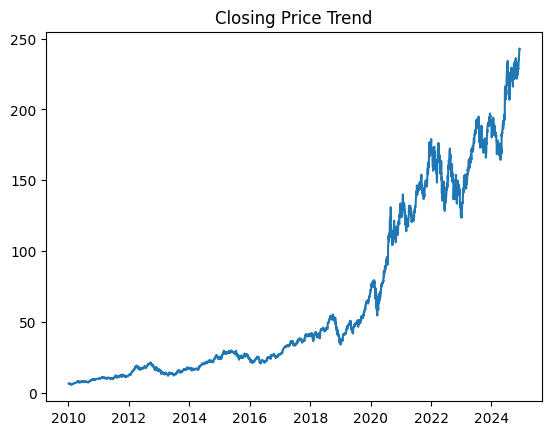

In [53]:
plt.plot(df['Date'],df['Close'])
plt.title("Closing Price Trend")
plt.show()

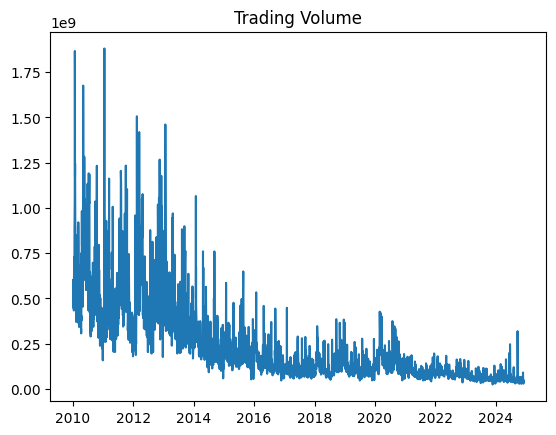

In [54]:
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume")
plt.show()

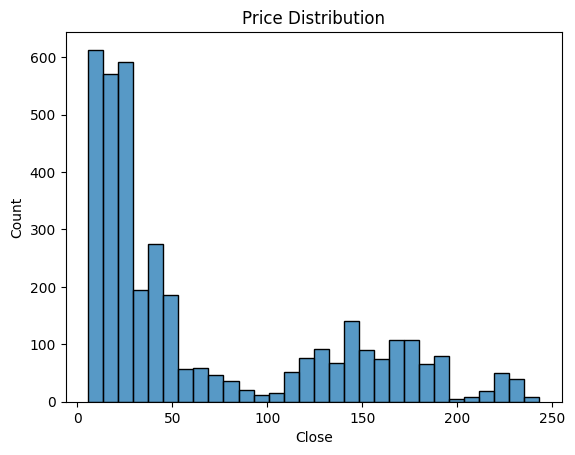

In [55]:
sns.histplot(df['Close'], bins=30)
plt.title("Price Distribution")
plt.show()

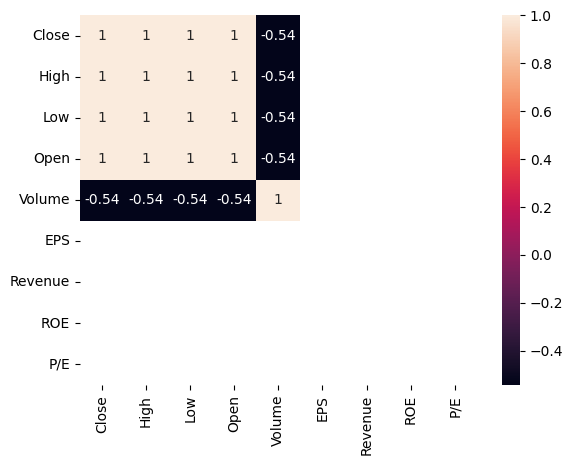

In [56]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [57]:
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

In [58]:
delta = df['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta <0, 0)).rolling(14).mean()


In [59]:
rs = gain / loss
df['RSI'] = 100 - (100/(1+rs))

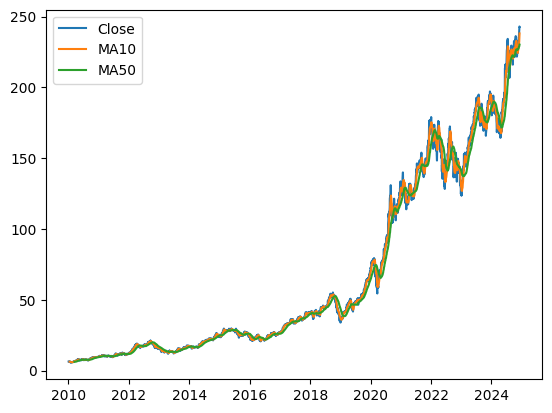

In [60]:
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_10'], label='MA10')
plt.plot(df['Date'], df['MA_50'], label='MA50')
plt.legend()
plt.show()

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [62]:
df = pd.read_csv('stock_data.csv')

In [63]:
df.dropna(inplace=True)

In [64]:
df.columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'EPS', 'Revenue',
       'ROE', 'P/E'],
      dtype='object')

In [65]:
X = df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'EPS', 'Revenue',
       'ROE', 'P/E']]

In [66]:
y =df['Close']

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
lr = LinearRegression()

In [71]:
X = df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'EPS', 'Revenue',
       'ROE', 'P/E']]

In [72]:
print(X.dtypes)

Date        object
Close      float64
High       float64
Low        float64
Open       float64
Volume       int64
EPS        float64
Revenue      int64
ROE        float64
P/E        float64
dtype: object


In [73]:
df = df.drop(columns=['Date'])

In [74]:
X = df[[ 'Close', 'High', 'Low', 'Open', 'Volume', 'EPS', 'Revenue',
       'ROE', 'P/E']]
y =df['Close']

In [75]:
df.rename(columns={'P/E': 'PE'}, inplace=True)

In [76]:
X = X.apply(pd.to_numeric)

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [78]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [79]:
lr.fit(X_train, y_train)

LinearRegression()

In [80]:
y_pred = lr.predict(X_test)

In [81]:
from sklearn.metrics import mean_squared_error, r2_score

In [82]:
from sklearn.metrics import r2_score

In [83]:
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [84]:
r2 = r2_score(y_test, y_pred)

In [85]:
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 4.251315929377117e-12
R2 Score: 1.0


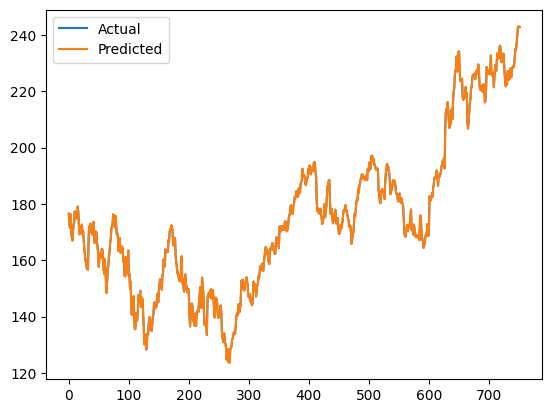

In [86]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

In [ ]:
##Summary:

- Dataset: Stock Market Data
- Techniques Used: Data Cleaning, Visualization, Feature Engineering
- Models Used: Linear Regression, Random Forest
- Evaluation Metrics; RMSE, R² Score
- Result: Model succesfully predicts stock trends

In [ ]:
##Conclusion :

In this project, we analyzed stock market data and built a machine
learning model to predict stock prices. We performed data preprocessing,
visualization, and feature engineering using indicators like Moving
Average and RSI.
We trained Linear Regression and Random Forest models. The random Forest
model showed better performance.
The model achieved very high accuracy (R² = 1.0), indicating strong
correlation between input feature and target variable.
However, this may also indicate overfitting due to highly related features
like Open, High, and Low.
The model is useful for understanding trends but may not always Predict
exact real-world stock prices.